**Function 4- Bayesian Optimisation**

# Function 4 Description

Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly.

To speed up decision-making, an ML model approximates these results within hours.

The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

# Starting point

* Input - 4D array (30,4)
* Output - 1D array (30,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
* BO with Upper Control Bound (UCB)
* Visuals of progress and surrogate intuition
* Final training with the optimized hyperparameters


### Import Libraries

In [18]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [19]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [20]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs4.npy')
    y_array = np.load('/content/data/initial_outputs4.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs4.npy')
        y_array = np.load('data/initial_outputs4.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(30, 4) # 30 samples, 4 features
       y_array = np.random.rand(30,)  #  30 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (30, 4)
Shape of y (NumPy array): (30,)

First 5 rows of X (DataFrame):


,0,1,2,3
0,0.896981,0.725628,0.175404,0.701694
1,0.889356,0.499588,0.539269,0.508783
2,0.250946,0.033693,0.145380,0.494932
3,0.346962,0.006250,0.760564,0.613024
4,0.124871,0.129770,0.384400,0.287076



First 5 rows of y (DataFrame):


,target_output
0,-22.108288
1,-14.601397
2,-11.699932
3,-16.053765
4,-10.069633


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [21]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 2 features per data point
# Let's add 4 new data points
new_X_points = np.array([
    [0.000001, 0.000001, 0.000001, 0.000001], # week 1 capstone submission - eye ball
    [0.999060, 0.812374, 0.514103, 0.985174], # week 2 capstone submission - KAPPA 30 exploration
    [0.906916, 0.260715, 0.311143, 0.816282], # week 3 capstone submission - KAPPA 30 exploration
    [0.405208, 0.813778, 0.300363, 0.116266], # week 4 capstone submission - KAPPA 100 for further exploration
    [0.305279, 0.206168, 0.358591, 0.994455], # week 5 capstone submission - KAPPA 200 for further exploration
    [0.931768, 0.981822, 0.034542, 0.188553], # week 6 capstone submission - KAPPA 500 for further exploration
    [0.906468, 0.836622, 0.035732, 0.995471], # week 7 capstone submission - KAPPA 300, changed the learning rate lower bound from 0.1 to 0.005 and increased the n_estimators upper bound based from 400 to 600 based on last two plots
    # and n_INTER from 8 to 30 for more warm up trials (as not seeing any improvement in RMSE for either bigger KAPPA values of 1000 or smaller KAPPA of 5.0)

    [0.677044, 0.156333, 0.998246, 0.566232], # week 8 capstone submission - KAPPA 300

    [0.415919, 0.368353, 0.319972, 0.402034], # week 9 capstone submission, using a KAPPA of 5 for Exploitation from BO
    [0.357388, 0.399078, 0.355108, 0.439288], # week 10 capstone submission, using a KAPPA of 2.5 for Exploitation from BO, changed N_INIT to 10 and N_ITER to 20.0
    [0.389407, 0.433478, 0.332875, 0.439437], # week 11 capstone submission, using a KAPPA of 1.0 for Exploitation from BO
    [0.378040, 0.399880, 0.303590, 0.439532]  # week 12 capstone submission, using a KAPPA of 1.0 for Exploitation from BO and added min_samples_leaf to search space
  # [0.395199, 0.340604, 0.332530, 0.430497]  # Week 13, KAAPA set to 0.25

])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    -25.27904427616762,   # week 1 capstone processed output
    -35.868116083037975,  # week 2 capstone processed output
    -21.036870852618744,  # week 3 capstone processed output
    -14.260173743879715,  # week 4 capstone processed output
    -19.168771713673703,  # week 5 capstone processed output
    -32.86166015962106,   # week 6 capstone processed output
    -37.95184478290381,   # week 7 capstone processed output
    -23.51600957580636,   # week 8 capstone processed output
    -0.20596649252200505, # week 9 capstone processed output
     0.4285161203451975,  # week 10 capstone processed output
     0.01802918385610086, # week 11 capstone processed output
    -1.0698747548941898   # week 12 capstone processed output
    # week 13 capstone processed output

])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (30, 4)
Original y shape: (30,)
New X points shape: (12, 4)
New y points shape: (12,)

Updated X shape: (42, 4)
Updated y shape: (42,)

Last 5 rows of updated X:


,0,1,2,3
37,0.677044,0.156333,0.998246,0.566232
38,0.415919,0.368353,0.319972,0.402034
39,0.357388,0.399078,0.355108,0.439288
40,0.389407,0.433478,0.332875,0.439437
41,0.378040,0.399880,0.303590,0.439532



Last 5 rows of updated y:


,target_output
37,-23.516010
38,-0.205966
39,0.428516
40,0.018029
41,-1.069875


Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values:
   Original Index: 39
   y value: 4.2851612035e-01
   Corresponding X values: [0.357388 0.399078 0.355108 0.439288]


   Original Index: 40
   y value: 1.8029183856e-02
   Corresponding X values: [0.389407 0.433478 0.332875 0.439437]


   Original Index: 38
   y value: -2.0596649252e-01
   Corresponding X values: [0.415919 0.368353 0.319972 0.402034]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 36
   y value: -3.7951844783e+01
   Corresponding X values: [0.906468 0.836622 0.035732 0.995471]


   Original Index: 31
   y value: -3.5868116083e+01
   Corresponding X values: [0.99906  0.812374 0.514103 0.985174]


   Original Index: 35
   y value: -3.2861660160e+01
   Corresponding X values: [0.931768 0.981822 0.034542 0.1885

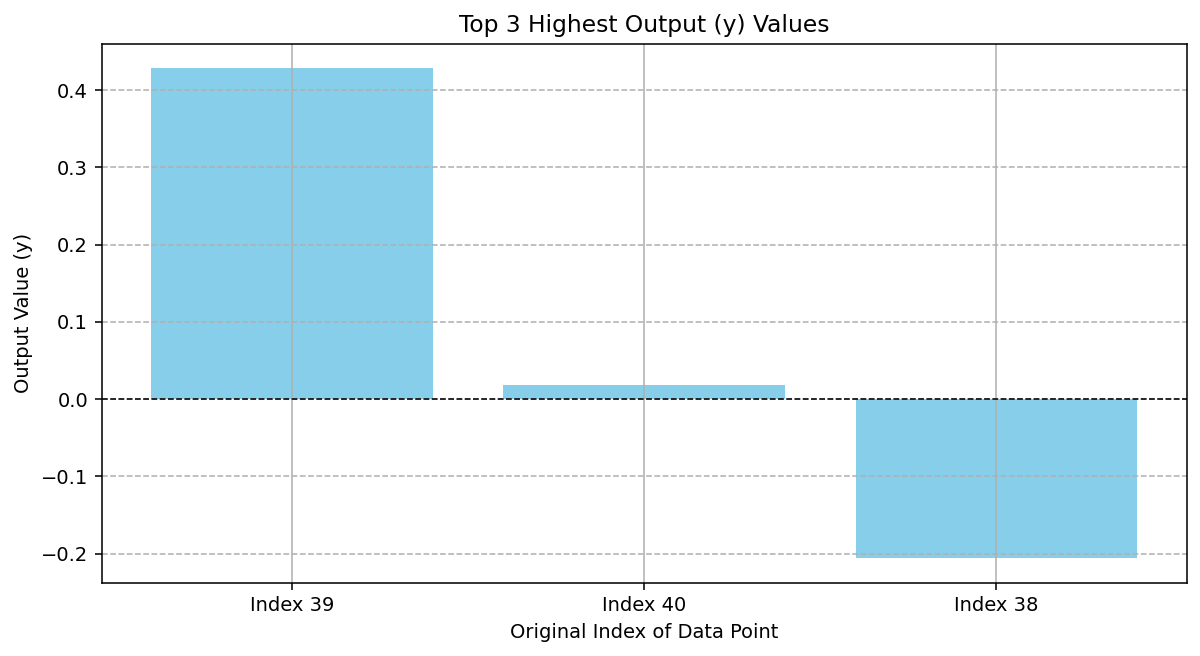

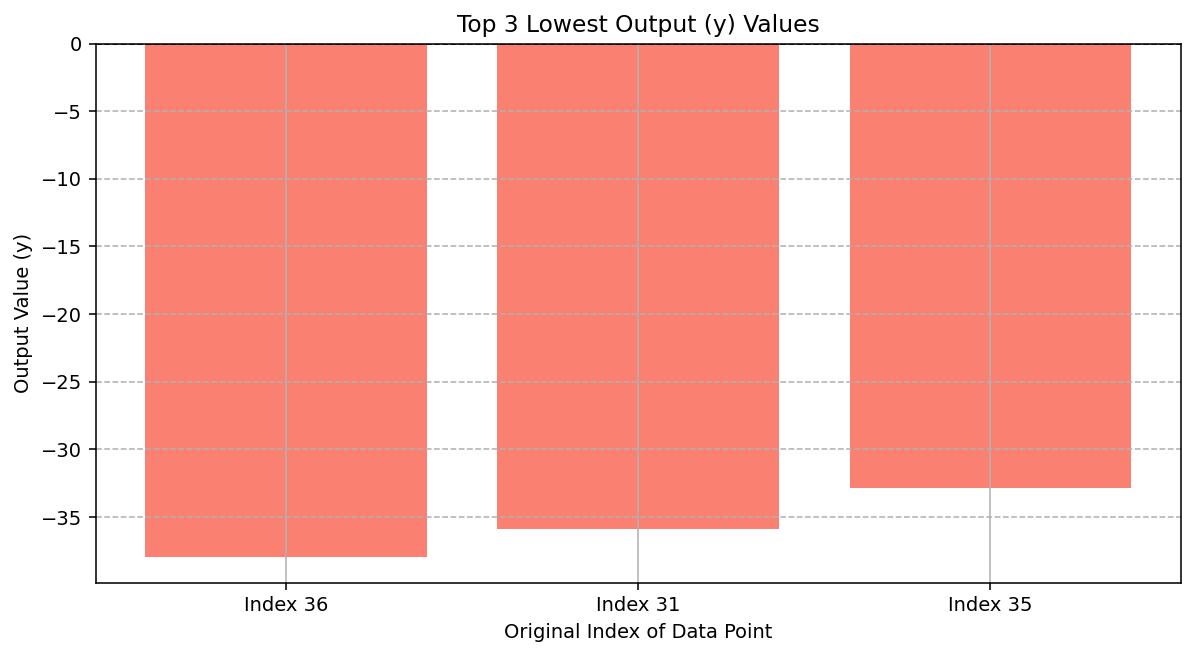

In [22]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

# Plotting the top 3 highest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_highest], top_3_y_highest, color='skyblue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Highest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

# Plotting the top 3 lowest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_lowest], top_3_y_lowest, color='salmon')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Lowest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [23]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 3.840


### Search Space and Helper Functions

In [24]:
# Search space for 4D input
space = {
    "n_estimators": (50,1200), # change from 400 to 600 based on the last two plots in week 7, changed to range from 50 to 1200 in week 8
    "learning_rate": (0.005, 0.30), # change lower bound to 0.005 from 0.01 based in last two plots
    "max_depth": (1, 10), # Added max_depth to search space
    "subsample": (0.5, 1.0), # Added subsample to search space
    "min_samples_leaf": (1, 20) # Added min_samples_leaf to search space
}
hp = list(space.keys()); d = len(hp) # d will now be 4

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers like n_estimators and max_depth)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth", "min_samples_leaf"]:
            v = int(round(v))
        out[name] = float(v)
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    if scipy_OK:
        return norm.pdf(z)
    return (1.0/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

def normal_cdf(z):
    if scipy_OK:
        return norm.cdf(z)
    return 0.5*(1+np.erf(z/np.sqrt(2)))

### Step by Step BO with UCB decomposition

#### Import Libraries

In [25]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [26]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

In [65]:
N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 0.25, 2000 # Exploitation Week 13, KAPPA 0.25
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 1.0, 2000 # Exploitation Week 12, KAPPA 1,0, added min_samples_leaf to search space
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 1.0, 2000 # Exploitation Week 11, KAPPA 1.0
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 2.5, 2000 # Exploitation Week 10, changed N_INIT and N_ITER (learning from function 5 strategy)
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 5.0, 2000 # Exploitation Week 9
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 30.0, 300.0, 2000 # Increased KAPPA to 300.0 for further exploration and number of warm up trials from 8 to 30 Weeks 7 and 8
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 0.1, 2000 # Set KAPPA to 0.1 for exploitation for Week 6
rng = np.random.RandomState(123)

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

#### Warm-up trials - BO needs some initial data to train the surrogate

In [66]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [67]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [68]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [69]:
import time

start_time = time.time()

for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Bayesian Optimization loop executed in {elapsed_time:.2f} seconds")

Bayesian Optimization loop executed in 45.33 seconds


The Bayesian Optimization loop executed in 53.48 seconds with a search space of n_estimators 50 to 600 (week 7).

This gives us a good benchmark for how long the hyperparameter tuning process takes with the current settings (N_INIT=8, N_ITER=30, KAPPA=300.0, N_CAND=2000). If you decide to increase N_ITER or N_CAND in the future, you can expect this time to increase, so it's a good metric to keep an eye on.

Latest iteration where I have increased the n_estimators range from 50 to 800 (week 8), the loop execution time is now 82.67 secs

Increasing it to 1000 as the n_estimators vs best rmse plot again showed the best rmse aorund 780, indicating I may need to widen the range (but keep in mind bias-variance tradeoff) - Bayesian Optimization loop executed in 81.84 seconds. Increasing it to 1200, the execution time was 88.28 seconds

#### Log final step log DataFrame

In [70]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(35)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,9.574203,9.574203,NaN,NaN,NaN,NaN,NaN,851.0,0.089411,3.0,0.775657,15.0
1,-8,Warm-up,4.694565,4.694565,NaN,NaN,NaN,NaN,NaN,537.0,0.294325,7.0,0.740466,8.0
2,-7,Warm-up,6.543339,4.694565,NaN,NaN,NaN,NaN,NaN,445.0,0.220070,5.0,0.529839,9.0
3,-6,Warm-up,5.741366,4.694565,NaN,NaN,NaN,NaN,NaN,899.0,0.058835,3.0,0.765776,11.0
4,-5,Warm-up,9.559324,4.694565,NaN,NaN,NaN,NaN,NaN,780.0,0.255582,8.0,0.805512,15.0
5,-4,Warm-up,9.600093,4.694565,NaN,NaN,NaN,NaN,NaN,421.0,0.111728,3.0,0.646857,13.0
6,-3,Warm-up,4.601474,4.601474,NaN,NaN,NaN,NaN,NaN,156.0,0.132942,5.0,0.746843,9.0
7,-2,Warm-up,5.692777,4.601474,NaN,NaN,NaN,NaN,NaN,409.0,0.130774,9.0,0.972080,11.0
8,-1,Warm-up,9.532562,4.601474,NaN,NaN,NaN,NaN,NaN,768.0,0.039107,4.0,0.707413,17.0
9,0,Warm-up,9.553618,4.601474,NaN,NaN,NaN,NaN,NaN,338.0,0.147495,10.0,0.759743,13.0


### Visuals

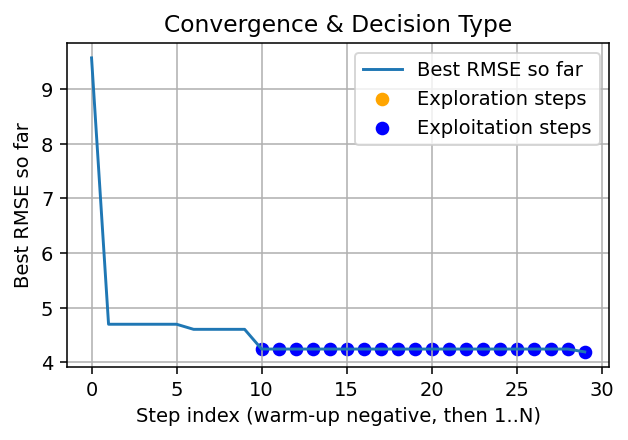

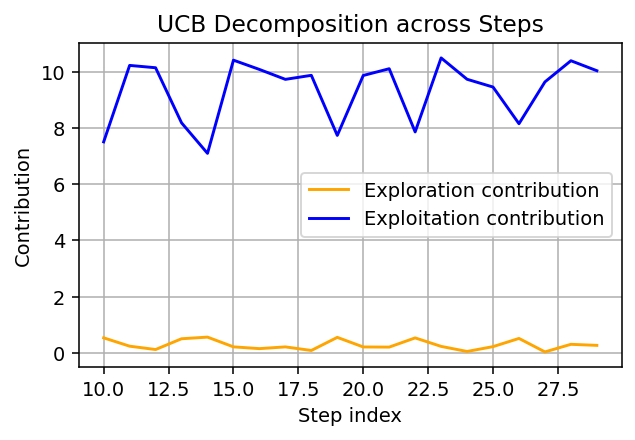

In [71]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

These two plots provide a summary of the Bayesian Optimisation process, drawing heavily from the data captured in your log_df:

**Convergence & Decision Type Plot:**

**What it shows:** This plot tracks the best_rmse_so_far column from your log_df over each iteration. The scatter points differentiate between 'Exploration steps' (orange) and 'Exploitation steps' (blue) as categorised by the 'tag' column in log_df.

**What it tells you:**
**Convergence:** You can observe how quickly the best_rmse_so_far value decreases and then stabilizes. A steep initial drop followed by a plateau indicates that the optimization found good solutions relatively early.

**Strategy:** The color of the points indicates the acquisition strategy chosen at each step. 'Exploration' steps mean the algorithm prioritized investigating regions of high uncertainty in the search space, while 'Exploitation' steps focused on regions where the model predicted a good RMSE. From your plot, it appears most steps were categorized as 'Exploration', which is expected with a KAPPA value of 300.0, indicating a strong preference for exploring uncertain regions.


**UCB Decomposition across Steps Plot: **

What it shows: This plot breaks down the components of the Upper Confidence Bound (UCB) acquisition function used to select the next point. It shows the exploit_contrib (blue line, related to the predicted mean mu from log_df) and explore_contrib (orange line, related to KAPPA * sigma from log_df) over the iterations.

**What it tells you:**

**Exploitation Contribution (blue line):** Represents how much the predicted low RMSE (good performance) in a region drives the selection of the next point. If this is high, the model is leveraging its current knowledge of good areas.

**Exploration Contribution (orange line)**: Represents how much the uncertainty (sigma) in a region, scaled by KAPPA, drives the selection of the next point. A high exploration contribution means the algorithm is trying to reduce uncertainty in poorly understood areas, hoping to find a new optimum.

**Balance:** This plot helps visualize the balance between exploring new areas versus exploiting known good areas. Given your KAPPA value of 300.0, it's clear that the 'Exploration contribution' significantly dominates the 'Exploitation contribution' throughout the BO process, reinforcing that the algorithm was aggressively searching new regions rather than just refining known ones.

In essence, these two plots, driven by the data in log_df, provide a powerful visual narrative of how your Bayesian Optimization is progressing, whether it's converging, and how it balances exploring new hyperparameter configurations with exploiting promising ones.

#### Surrogate slice: initial vs final (hyperparameters in search space)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

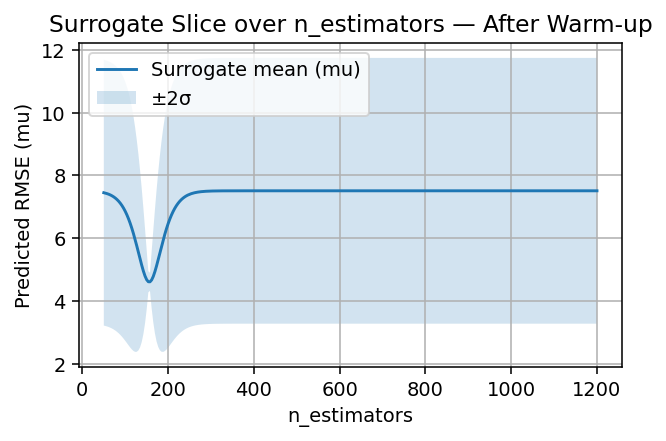

--- 2-sigma range for 'n_estimators' - 'After Warm-up' ---
Minimum of (mu - 2*std): 2.3741
Maximum of (mu + 2*std): 11.7448
------------------------------


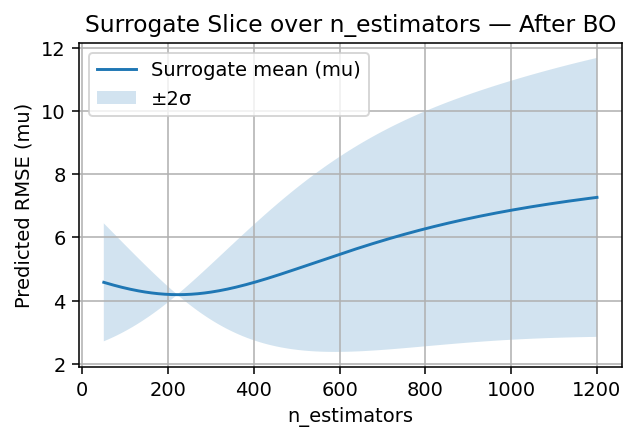

--- 2-sigma range for 'n_estimators' - 'After BO' ---
Minimum of (mu - 2*std): 2.3730
Maximum of (mu + 2*std): 11.6924
------------------------------


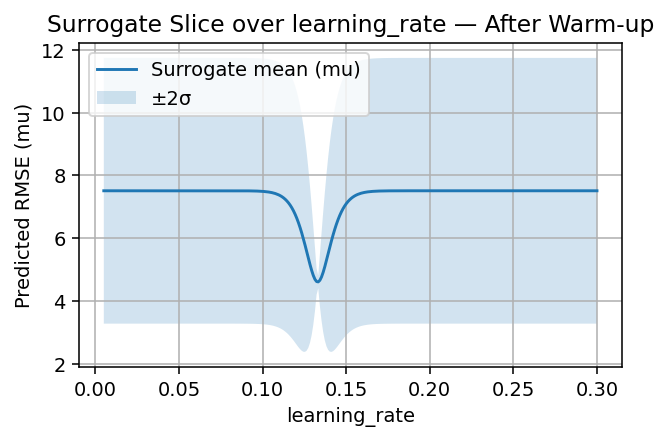

--- 2-sigma range for 'learning_rate' - 'After Warm-up' ---
Minimum of (mu - 2*std): 2.3727
Maximum of (mu + 2*std): 11.7448
------------------------------


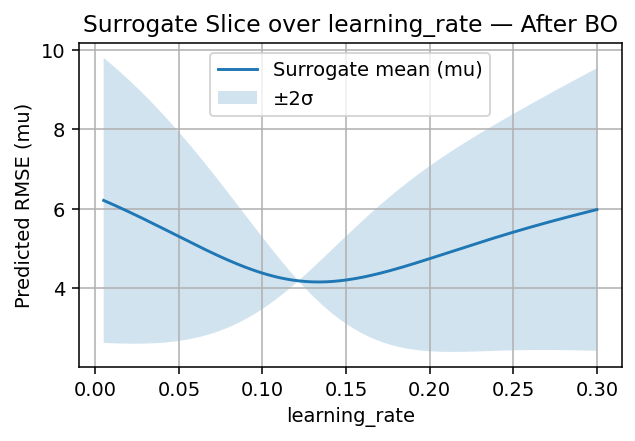

--- 2-sigma range for 'learning_rate' - 'After BO' ---
Minimum of (mu - 2*std): 2.3995
Maximum of (mu + 2*std): 9.7984
------------------------------


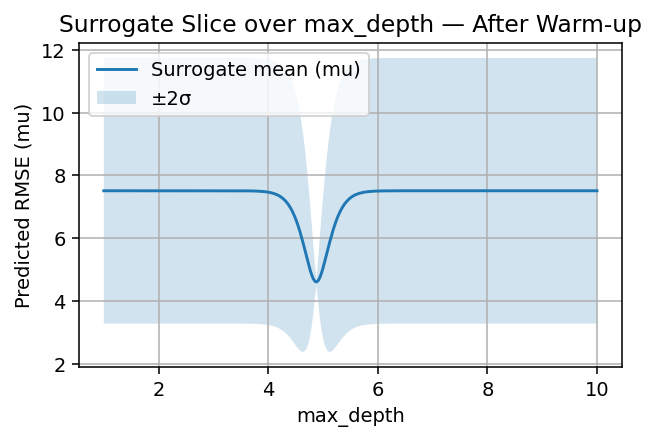

--- 2-sigma range for 'max_depth' - 'After Warm-up' ---
Minimum of (mu - 2*std): 2.3719
Maximum of (mu + 2*std): 11.7448
------------------------------


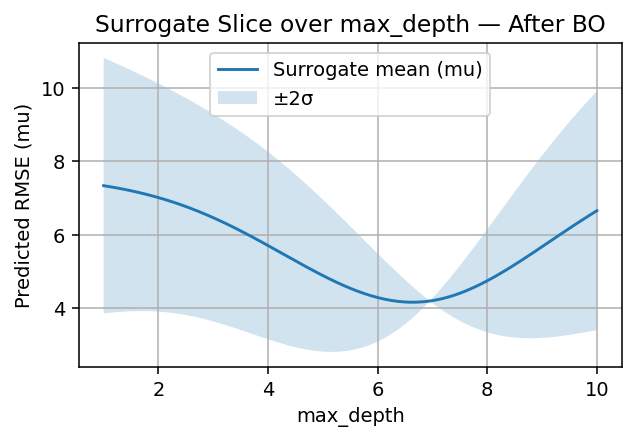

--- 2-sigma range for 'max_depth' - 'After BO' ---
Minimum of (mu - 2*std): 2.7992
Maximum of (mu + 2*std): 10.8173
------------------------------


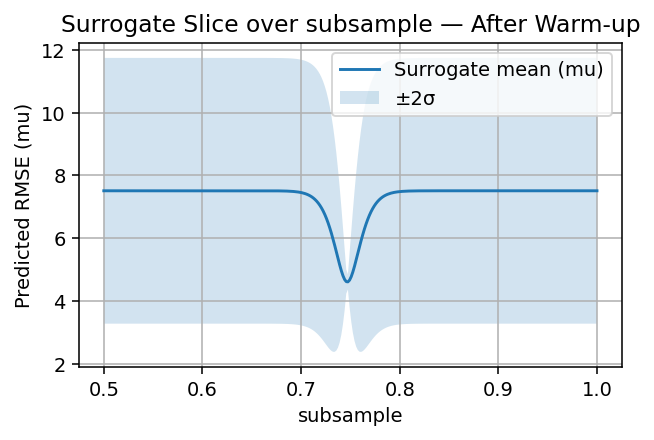

--- 2-sigma range for 'subsample' - 'After Warm-up' ---
Minimum of (mu - 2*std): 2.3733
Maximum of (mu + 2*std): 11.7448
------------------------------


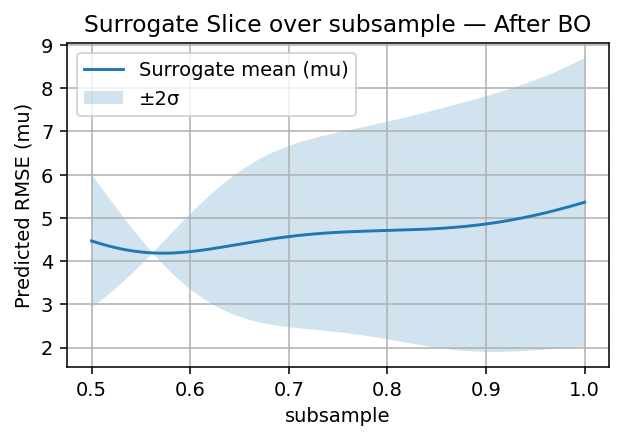

--- 2-sigma range for 'subsample' - 'After BO' ---
Minimum of (mu - 2*std): 1.8984
Maximum of (mu + 2*std): 8.6990
------------------------------


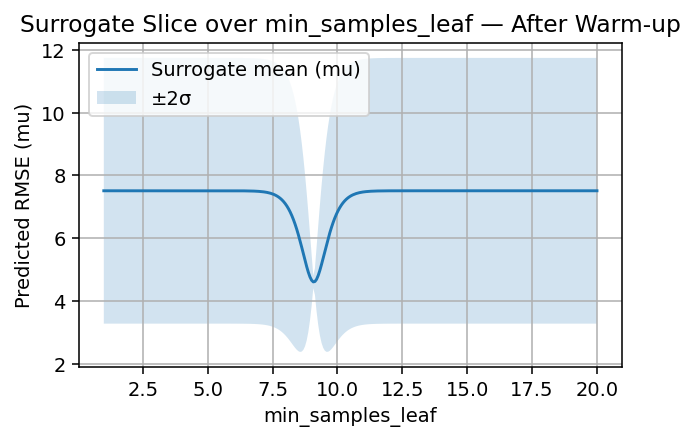

--- 2-sigma range for 'min_samples_leaf' - 'After Warm-up' ---
Minimum of (mu - 2*std): 2.3727
Maximum of (mu + 2*std): 11.7448
------------------------------


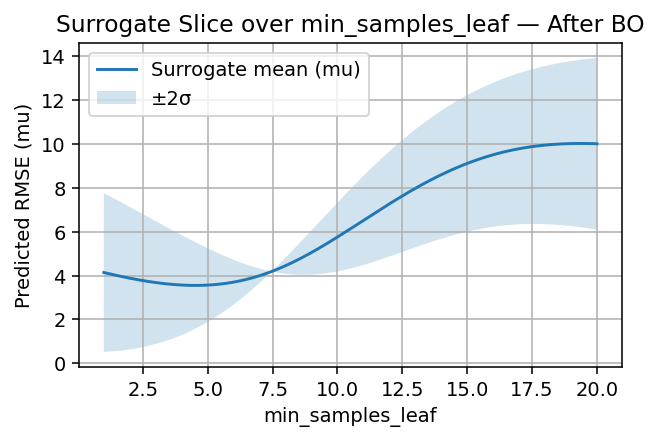

--- 2-sigma range for 'min_samples_leaf' - 'After BO' ---
Minimum of (mu - 2*std): 0.5220
Maximum of (mu + 2*std): 13.9210
------------------------------


In [72]:
import numpy as np

def surrogate_slice_plot(X_used, y_used, title_suffix, param_name):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(param_name)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[param_name]; param_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(param_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(param_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(param_name); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {param_name} — {title_suffix}")
    plt.legend(); plt.show()

    # Print the 2-sigma range
    print(f"--- 2-sigma range for '{param_name}' - '{title_suffix}' ---")
    lower_bound = mu - 2 * std
    upper_bound = mu + 2 * std
    print(f"Minimum of (mu - 2*std): {np.min(lower_bound):.4f}")
    print(f"Maximum of (mu + 2*std): {np.max(upper_bound):.4f}")
    print("-" * 30)

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in space.keys():
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", hp_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", hp_name)

The two 'Surrogate Slice over learning_rate' plots provide a visual representation of how the Gaussian Process (GP) surrogate model has learned and refined its understanding of the objective function (RMSE) with respect to the learning_rate hyperparameter.

Breakdown of whhat each plot shows:

**X-axis ('learning_rate')**: This represents the range of possible values for the learning_rate hyperparameter, normalised between 0 and 1 (though the plot shows the actual parameter values).

**Y-axis ('Predicted Negative R2 (mu)')**: This indicates the predicted Negative R2 score. Since we are minimizing RMSE, lower values on the y-axis are better.

**Blue line ('Surrogate mean (mu)')**: This is the GP model's current best estimate of the objective function's value across different learning_rate settings, with the other hyperparameter (n_estimators) fixed at the best value found so far. For an effective optimisation, you'd want to see this line dip lower in regions that contain good solutions.

**Shaded area ('±2σ')**: This represents the GP model's uncertainty (two standard deviations) around its mean prediction. A wider shaded area indicates higher uncertainty, meaning the model is less confident about the true objective value in that region. A narrower band indicates lower uncertainty.

**Comparing 'After Warm-up' and 'After BO'**:

**'After Warm-up'**: This plot reflects the GP's initial understanding, based solely on the randomly chosen warm-up trials (the first N_INIT entries in log_df). You'll typically see broader uncertainty (wider ±2σ band) because the model has limited information about the search space. The mean prediction might be less smooth or accurate.

**'After BO'**: This plot shows the refined understanding after the Bayesian Optimisation iterations have completed (all entries in log_df are considered). The log_df has accumulated more targeted data points where the acquisition function (UCB in this case) suggested exploring or exploiting. As a result:

The uncertainty (±2σ band) tends to narrow in regions that the BO process has explored more thoroughly, showing increased confidence in the predictions.
The surrogate mean (blue line) often shows a clearer minimum, indicating where the model predicts the best learning_rate lies for minimising RMSE. This minimum is influenced by the observed rmse values in the log_df.

In essence, these plots visually demonstrate how the Bayesian Optimization process, by selectively adding data points to our X_trials and y_trials (and consequently enriching our log_df), progressively reduces uncertainty and builds a more accurate 'map' of the hyperparameter landscape to guide the search for optimal configurations.


**Weekly Strategy**

1. **Week 4** using a KAPPA of 100.0, best candidate offered was [0.405208, 0.813778, 0.300363, 0.116266]
2. **Week 5** using a bigger KAPPA of 200.00 for more exploration, best candidate offered is [0.30527931, 0.2061683 , 0.35859122, 0.99445456]
3. **Week 6** using a KAPPA of 500.0, best candidate offered was [0.93176753, 0.98182213, 0.03454226, 0.18855275], achieving a much smaller
4. **Week 7** using a KAPPA 300, changed the learning rate lower bound
  from 0.1 to 0.005 and increased the n_estimators upper bound based from 400 to 600 based on last two plots and n_INTER from 8 to 30 for more warm up trials (as not seeing any improvement in RMSE for either bigger KAPPA values of 1000 or smaller KAPPA of 5.0)   [0.90646766, 0.83662169, 0.03573166, 0.99547128]

5. **Week 8** using a KAPPA 300 changed the n_estimators range from 50 to 600 to 50 to 1200 due to the last two plots. Notes in increased time to execute loop noted and conscious of bias vs variance tradeoff. This yielded a slightly better rmse



**Hyperparamter tuning consideration in Week 8**

Based on these two plots below and this summary after week 7:

# The current settings for your hyperparameters are as follows Week 7:

Search Space (defined in the space dictionary):

n_estimators: From 50 to 600
learning_rate: From 0.005 to 0.30
max_depth: From 1 to 10
subsample: From 0.5 to 1.0
Optimized Hyperparameters (from the best performing run in Bayesian Optimization):

n_estimators: 594
learning_rate: 0.17149
max_depth: 1
subsample: 0.586775

These optimized values represent the combination of hyperparameters that yielded the best RMSE (3.019) during the Bayesian Optimisation process.

For **week 8**, it would make sense to adjust the n_Estimators range **from 50 to 600 to 100 to 800** as the optimised hyperparamter values of 594 is at the edge of the search space. After running the code the n_estimators plot was showing best rmse at the upper end of 800, so I decided to explore extending the upper range further, firstly to 1000 and then 1,200. I noted that the best learning rate then moved to the upper end of the search space settings to around 0.28 when I had shfted the n_estimator upper end range to 1,200. This illustrates that these two hyperparameters are inderdependent on eachother.    



**Week 9, KAPPA 5.0 from BO**

 - Suggested next X data point (4D coordinates): [0.41591874 0.36835311 0.31997155 0.40203374]
 - Predicted Y at this point (mean): -2.16503e+00
 - Predicted uncertainty (std) at this point: 7.19409e-01
 - UCB value at this point: 1.43202e+00

**Week 10, KAAP 2.5 from BO, changed N_INIT to 10 and N_ITER to 20**

 - Suggested next X data point (4D coordinates): [0.35738776 0.39907783 0.35510795 0.43928844]
 - Predicted Y at this point (mean): -3.68625e-01
 - Predicted uncertainty (std) at this point: 2.93014e-01
 - UCB value at this point: 3.63908e-01



**Week 11, KAAPA set to 1.0 from BO**

 - Suggested next X data point (4D coordinates): [0.38940718 0.43347817 0.33287489 0.43943726]
 - Predicted Y at this point (mean): 2.16068e-01
 - Predicted uncertainty (std) at this point: 3.31990e-01
 - UCB value at this point: 5.48058e-01

### **Week 12, KAAPA set to 1.0 from BO and added min_samples_leaf as per in functions 2 and 3**

 - Suggested next X data point (4D coordinates): [0.37804017 0.39988006 0.30359014 0.43953191]
 - Predicted Y at this point (mean): -9.06564e-03
 - Predicted uncertainty (std) at this point: 2.94035e-01
 - UCB value at this point: 2.84969e-01

### **Week 13, KAAPA set to 0.25 from BO**

 - Suggested next X data point (4D coordinates): [0.3951985  0.34060351 0.33252982 0.4304965 ]
 - Predicted Y at this point (mean): -5.26825e-01
 - Predicted uncertainty (std) at this point: 5.34666e-01
 - UCB value at this point: -3.93159e-01

### Final Model (on best parameters)

Optimized hyperparameters (from BO): {'n_estimators': 221, 'learning_rate': 0.12151518516743089, 'max_depth': 7, 'subsample': 0.5619329417623249, 'min_samples_leaf': 7.0}
Final (BO) 5-fold RMSE: 3.86


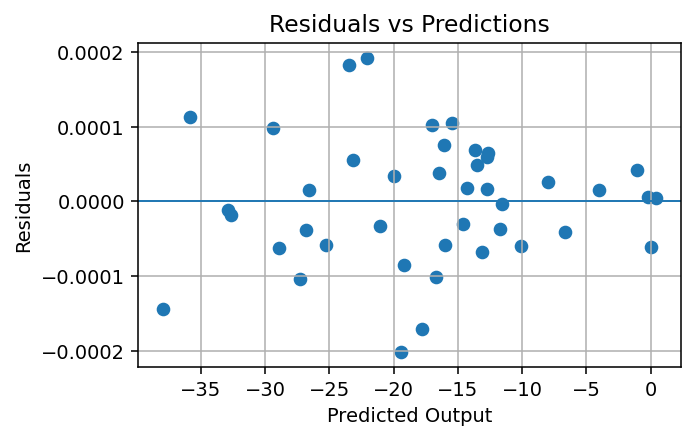

In [73]:
# The original values for max_depth and subsample were fixed within the objective function.
# We need to use those same fixed values here to initialize the final model.
# Removed fixed_max_depth and fixed_subsample as they are now part of the optimized space.

best_row = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]
best_params = {k: float(best_row[k]) for k in space.keys()}
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"]) # Ensure max_depth is an integer

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the optimized value
    subsample=best_params["subsample"], # Use the optimized value
    random_state=42
)
final_rmse = rmse_cv(final)
print("Final (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

# Pattern of Spread:

Instead of a constant spread (Homoscedasticity), the residuals appear to fan out or narrow at different points. Specifically, at the lower and higher ends of the 'Predicted Output' (X-axis), the vertical spread of the residuals appears to be larger than in the middle range. This 'cone' or 'funnel' shape is a classic sign of heteroscedasticity.

# Implications of Heteroscedasticity:

When heteroscedasticity is present, it means that the model's errors are not consistent across the range of its predictions:

**Unequal Reliability:** The model's predictions are less reliable or have a higher variance in error for certain ranges of output, often at the extremes (as you noted at the ends). In your case, it suggests the model might be less confident or less accurate when predicting very low or very high y values.

**Biased Error Estimates**: Standard error estimates for the model's coefficients (if you were looking at a simpler linear model) might be biased, making you over- or underestimate the true precision of your predictions in different regions.

**Suboptimal Performance:** It indicates that the model might be missing some non-linear relationships or that the features might have a different impact on the target y at different scales. This means there's still room for the model to improve its predictive power in those regions.

**Addressing heteroscedasticity often involves:**

**Feature Engineering**: Adding new features or transforming existing ones that might capture the non-linearities the model is missing.

**Target Transformation**: Applying transformations (e.g., logarithmic) to the y variable if its variance is proportional to its mean.

**Using More Robust Models**: Some models are naturally more robust to heteroscedasticity than others.

### Log review (each step)

In [74]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(40)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,9.574203,9.574203,NaN,NaN,NaN,NaN,NaN,851.0,0.089411,3.0,0.775657,15.0
1,-8,Warm-up,4.694565,4.694565,NaN,NaN,NaN,NaN,NaN,537.0,0.294325,7.0,0.740466,8.0
2,-7,Warm-up,6.543339,4.694565,NaN,NaN,NaN,NaN,NaN,445.0,0.220070,5.0,0.529839,9.0
3,-6,Warm-up,5.741366,4.694565,NaN,NaN,NaN,NaN,NaN,899.0,0.058835,3.0,0.765776,11.0
4,-5,Warm-up,9.559324,4.694565,NaN,NaN,NaN,NaN,NaN,780.0,0.255582,8.0,0.805512,15.0
5,-4,Warm-up,9.600093,4.694565,NaN,NaN,NaN,NaN,NaN,421.0,0.111728,3.0,0.646857,13.0
6,-3,Warm-up,4.601474,4.601474,NaN,NaN,NaN,NaN,NaN,156.0,0.132942,5.0,0.746843,9.0
7,-2,Warm-up,5.692777,4.601474,NaN,NaN,NaN,NaN,NaN,409.0,0.130774,9.0,0.972080,11.0
8,-1,Warm-up,9.532562,4.601474,NaN,NaN,NaN,NaN,NaN,768.0,0.039107,4.0,0.707413,17.0
9,0,Warm-up,9.553618,4.601474,NaN,NaN,NaN,NaN,NaN,338.0,0.147495,10.0,0.759743,13.0


In [75]:
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Best RMSE found: {log_df['best_rmse_so_far'].min():.4f}")

Baseline RMSE: 3.8398
Best RMSE found: 4.1877


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (4D coordinates) to sample in this drug discovery project we will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (4D coordinates) and y (disatnce from expensive baseline). Generate a grid of candidate points across the 4D input space. Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point. Identify the candidate point with the highest acquisition function value as the next suggested x for sampling.

In [76]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 4D search space for combination of drugs
# The X values represent amounts of four compounds, typically normalized between [0, 1]
x_space = [(0, 1), (0, 1), (0, 1), (0, 1)] # Define the bounds for each of the four X features

d_x = X.shape[1] # Dimension of the X input space (should be 4 for the drug compounds)

# 2. Initialize and fit a Gaussian Process Regressor on the existing drug compound data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 4D input space
n_candidates_3d = 10000 # Number of candidate points for the 4D search space

# Create a uniform grid of candidates within the defined x_space
# For simplicity, we'll generate random candidates within the bounds [0,1] for all four features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function
# We need to decide on a KAPPA for this 4D search. A higher KAPPA means more exploration.
KAPPA_3D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 4D space

# Since we are trying to MAXIMIZE the (transformed) output (minimizing side effects),
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the maximum UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (4D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 4D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 4D coordinates.

Suggested next X data point (4D coordinates): [0.3951985  0.34060351 0.33252982 0.4304965 ]
Predicted Y at this point (mean): -5.26825e-01
Predicted uncertainty (std) at this point: 5.34666e-01
UCB value at this point: -3.93159e-01


#Hyperparameter: n_estimators

In the context of your Bayesian Optimization as captured in log_df, **n_estimators** is a crucial hyperparameter for the GradientBoostingRegressor model.

It represents the number of boosting stages, or individual decision trees, that the algorithm builds sequentially. Each tree attempts to correct the errors of the previous ones.

**Too few n_estimators:** The model might underfit, not capturing enough complexity in the data.

**Too many n_estimators:** The model can overfit, learning noise in the training data and performing poorly on unseen data, and also significantly increase training time, as I observed when widening the search space from 800 to 1200.

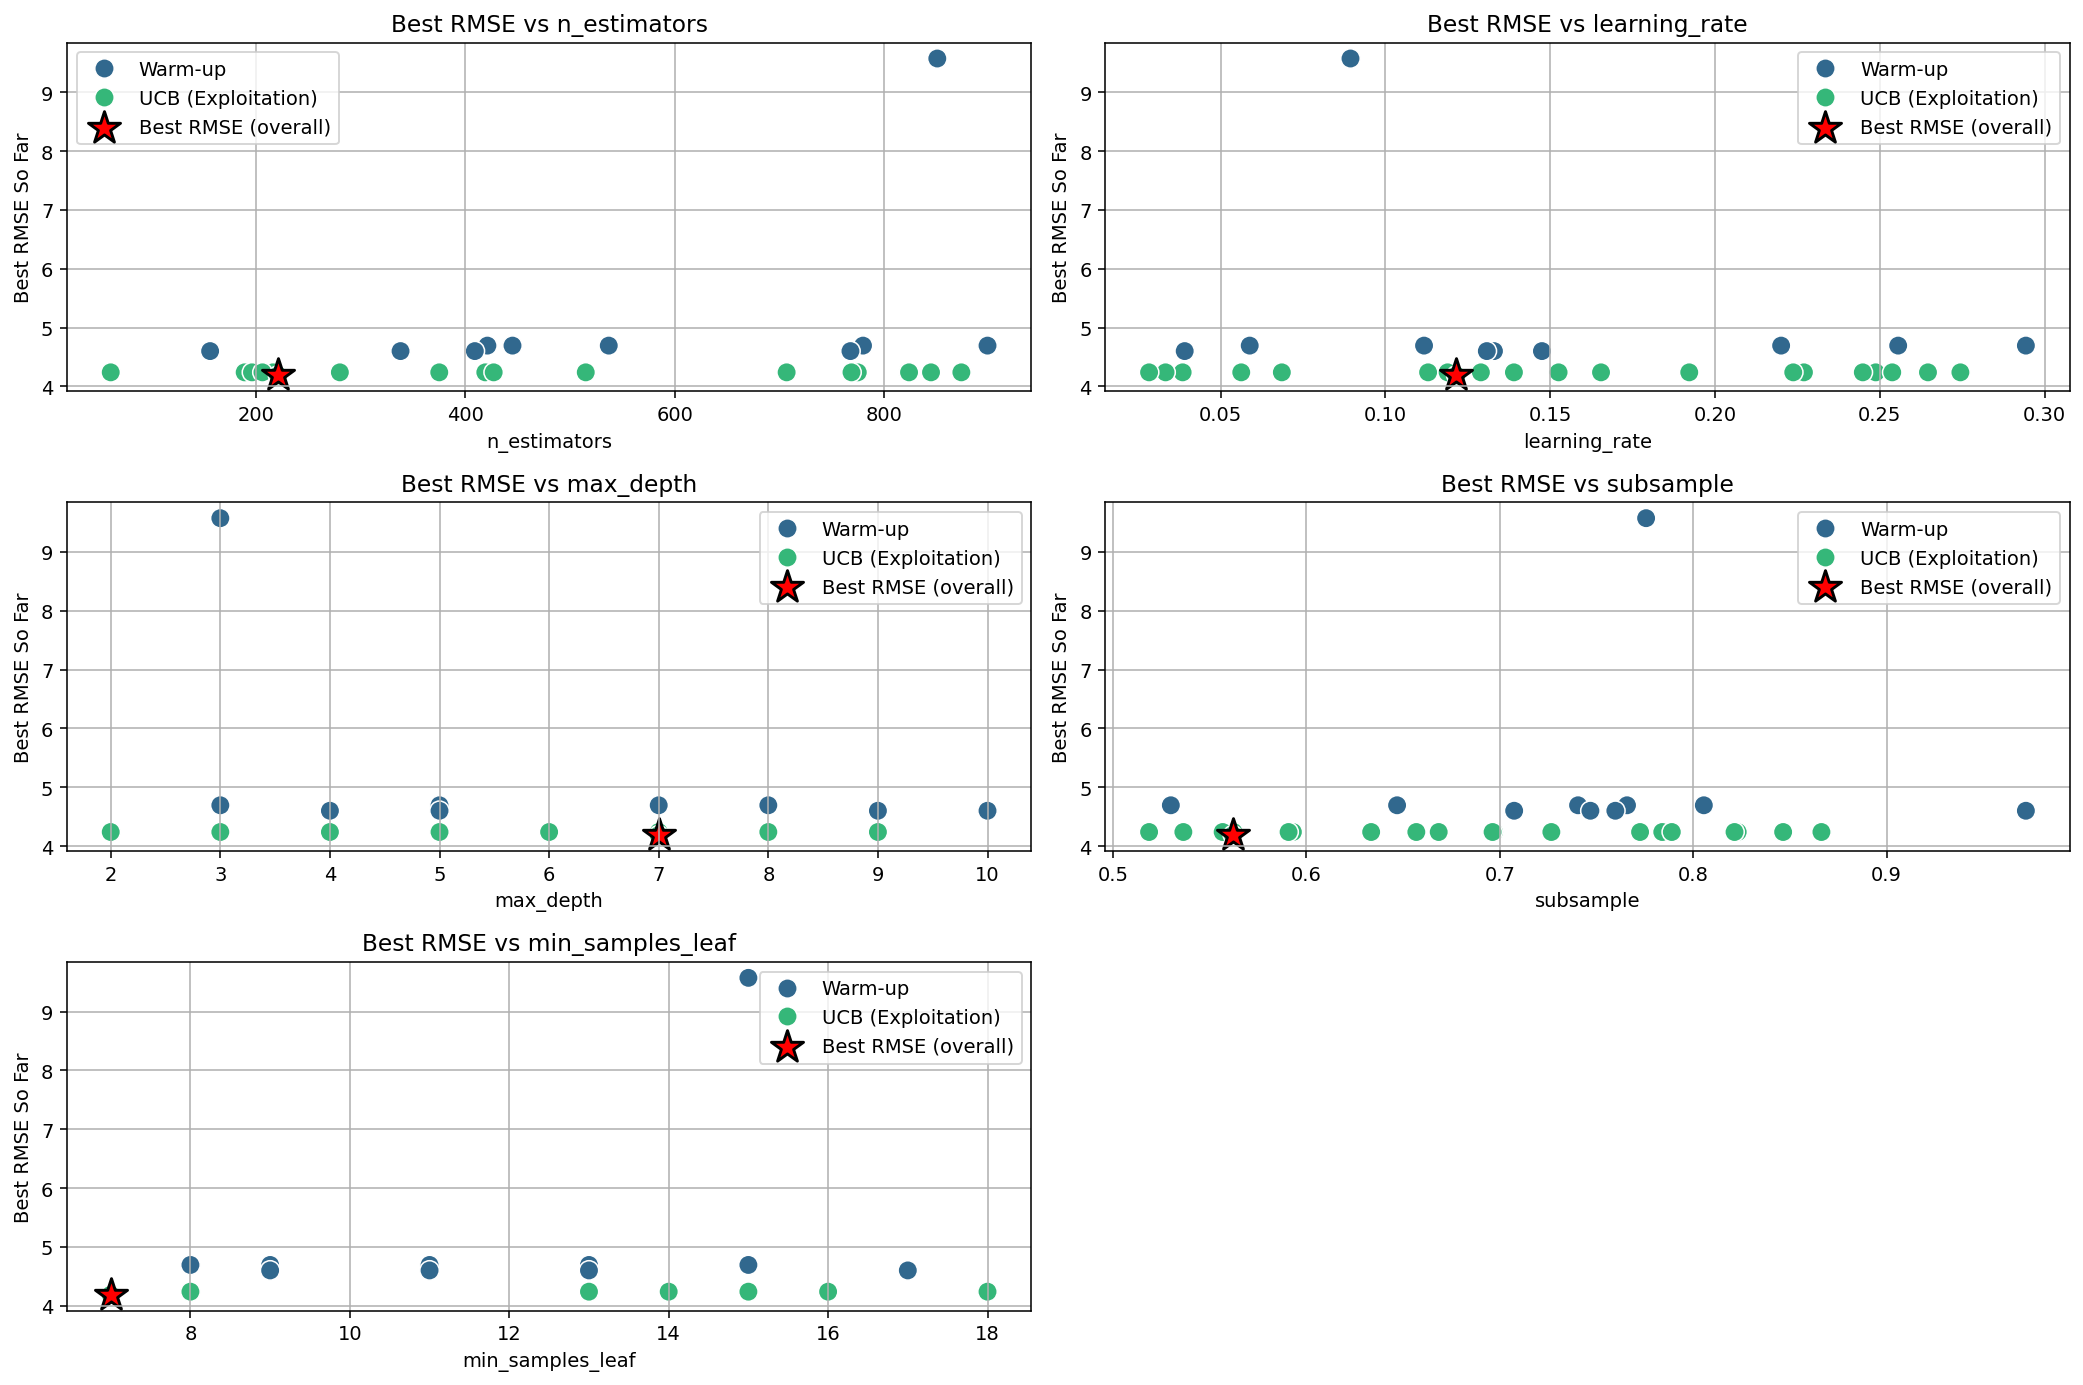

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.scatterplot(data=log_df, x=hp_name, y='best_rmse_so_far', hue='tag', palette='viridis', s=100)

    # Get the best RMSE and its corresponding row across all hyperparameters
    best_rmse_val_overall = log_df['best_rmse_so_far'].min()
    best_row = log_df[log_df['best_rmse_so_far'] == best_rmse_val_overall].iloc[0]

    # Highlight the best overall RMSE point for the current hyperparameter
    best_hp_value = best_row[hp_name]
    best_rmse_value = best_row['best_rmse_so_far']
    plt.scatter(best_hp_value, best_rmse_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best RMSE (overall)')

    plt.title(f'Best RMSE vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best RMSE So Far')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

#Hyperparameter: learning_rate

The **learning_rate** is another critical hyperparameter in Gradient Boosting models, which heavily influences how much the model learns from each subsequent tree.

**learning_rate:** This controls the step size at each iteration while moving towards a minimum of the loss function. A smaller learning rate requires more n_estimators to achieve the same reduction in loss, but it can lead to a more robust model that is less prone to overfitting. A larger learning rate can converge faster but might overshoot the optimal solution or get stuck in local minima.

# Interdependence with n_estimators: These two hyperparameters are highly interdependent.

If you decrease the learning_rate, you typically need to increase n_estimators to compensate. A smaller step size means more steps are required to reach the optimal solution.

Conversely, if you increase the learning_rate, you might need to decrease n_estimators. This is because larger steps mean the model converges faster, and adding too many trees with large steps can quickly lead to overfitting.

Your observation that the 'best learning rate then moved to the upper end of the search space settings to around 0.28 when I had shifted the n_estimator upper end range to 1,200' is a perfect illustration of this interdependence.

When you allow for more trees (higher n_estimators), the model can afford to take smaller steps (lower learning_rate) to refine its predictions more carefully, or if it finds that more trees improve the model, it might also find a slightly higher learning rate allows it to converge to a better solution faster within that expanded n_estimators range.

# Finding the right balance between these two is key to optimizing the GradientBoostingRegressor.

**4D Scatter Plot of Observed Data:** This plot visualizes the first three features of your observed input data (X[:, 0], X[:, 1], X[:, 2]) in a 3D scatter plot. The fourth dimension, your target output (y), is represented by the color of the points. This helps you get an intuitive sense of how your target values are distributed across a subset of your input features.

**4D Slice Plot for Surrogate Mean (Features 3 and 4 fixed at 0.5)**: This 3D surface plot shows the Gaussian Process model's prediction of the mean target output (mu) across a 2D slice of your 4D input space. Specifically, it varies Feature 1 (X[:, 0]) and Feature 2 (X[:, 1]) while holding Feature 3 (X[:, 2]) and Feature 4 (X[:, 3]) constant at a value of 0.5. The red points indicate actual observed data points that fall within a small tolerance of these fixed feature values, providing context for the surrogate's predictions.

**4D Slice Plot for Surrogate Uncertainty (Features 3 and 4 fixed at 0.5)**: Similar to the mean plot, this 3D surface plot displays the Gaussian Process model's predicted standard deviation (sigma) for the same 2D slice (Features 1 and 2 varying, Features 3 and 4 fixed at 0.5). Higher areas on this surface indicate regions where the model has greater uncertainty about the true target output. These are often areas where the Bayesian Optimization algorithm might suggest exploring next to reduce uncertainty and potentially find better solutions. The red points again show observed data points in this slice.

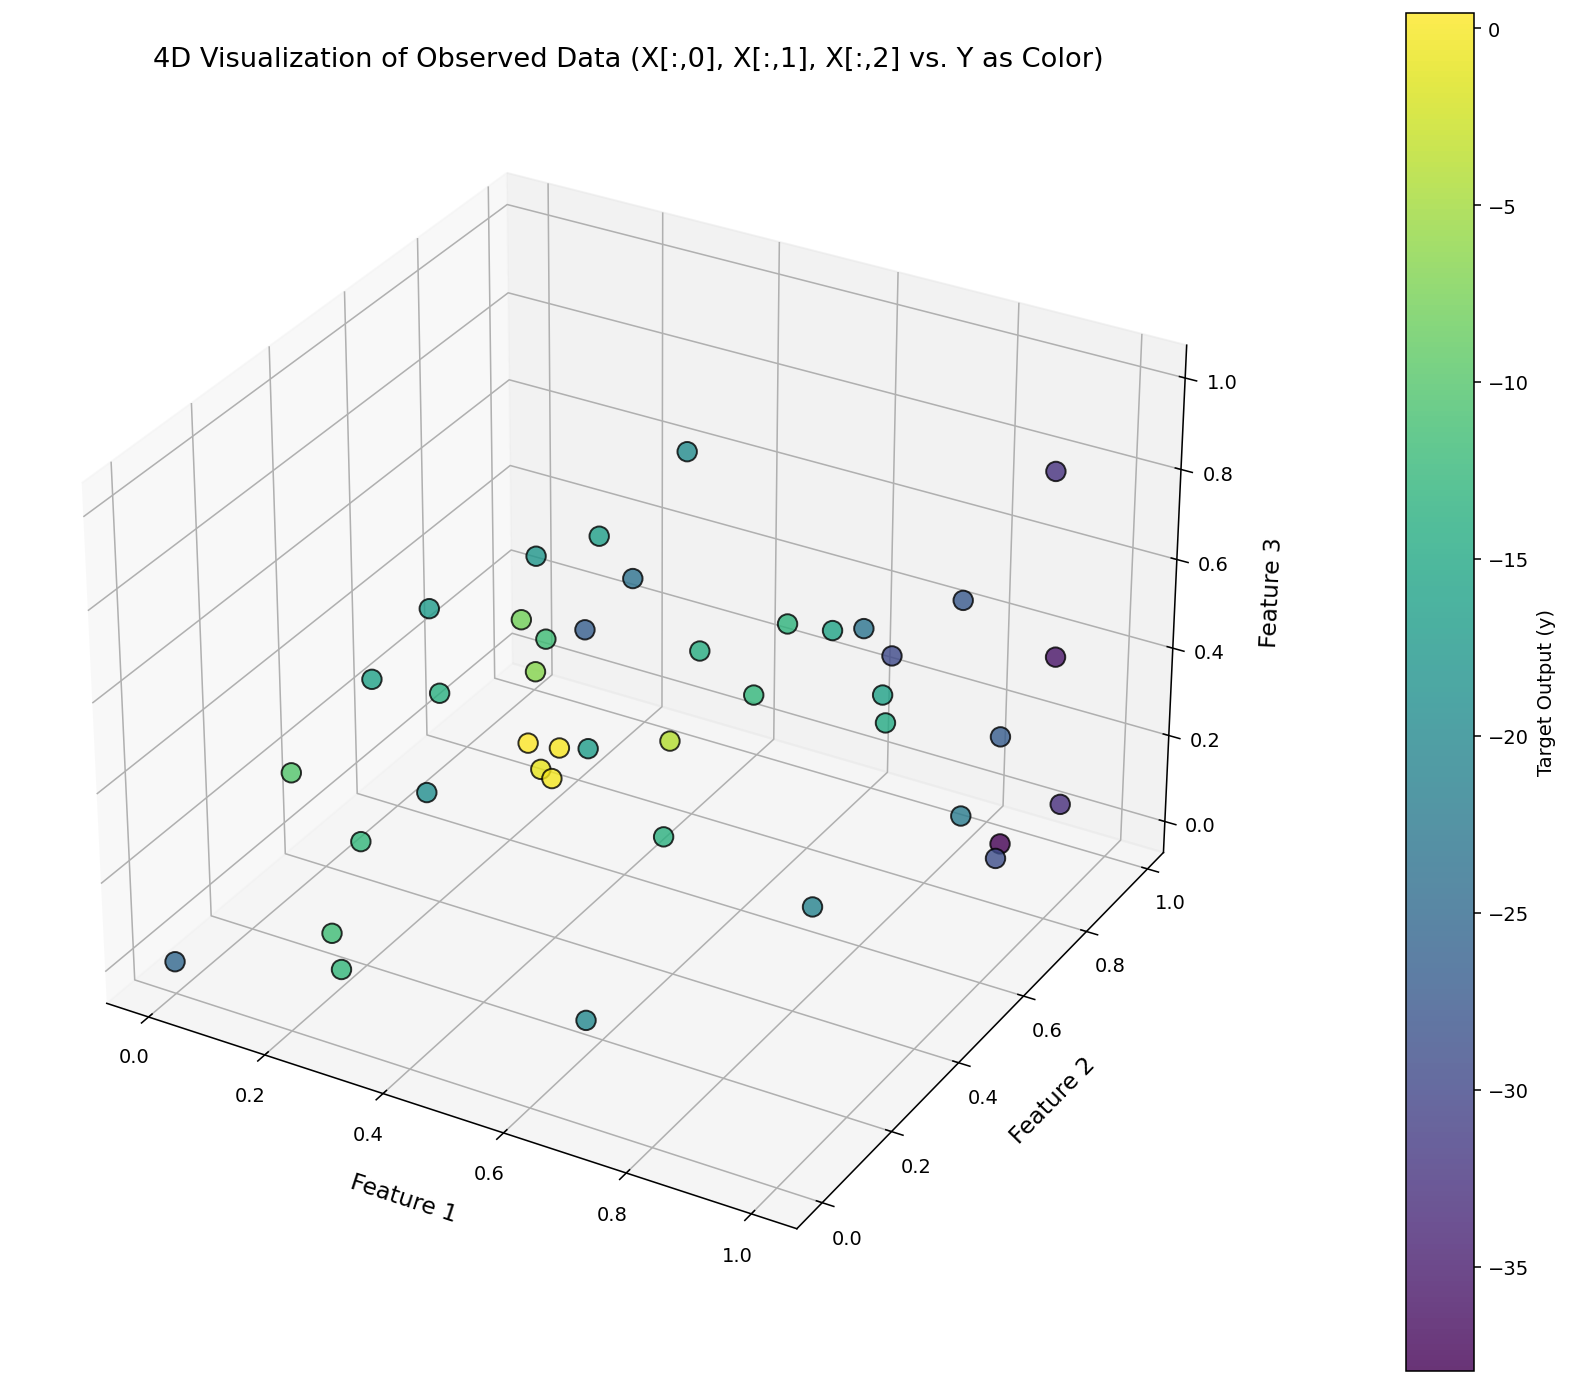

Displayed: 4D Scatter Plot of Observed Data


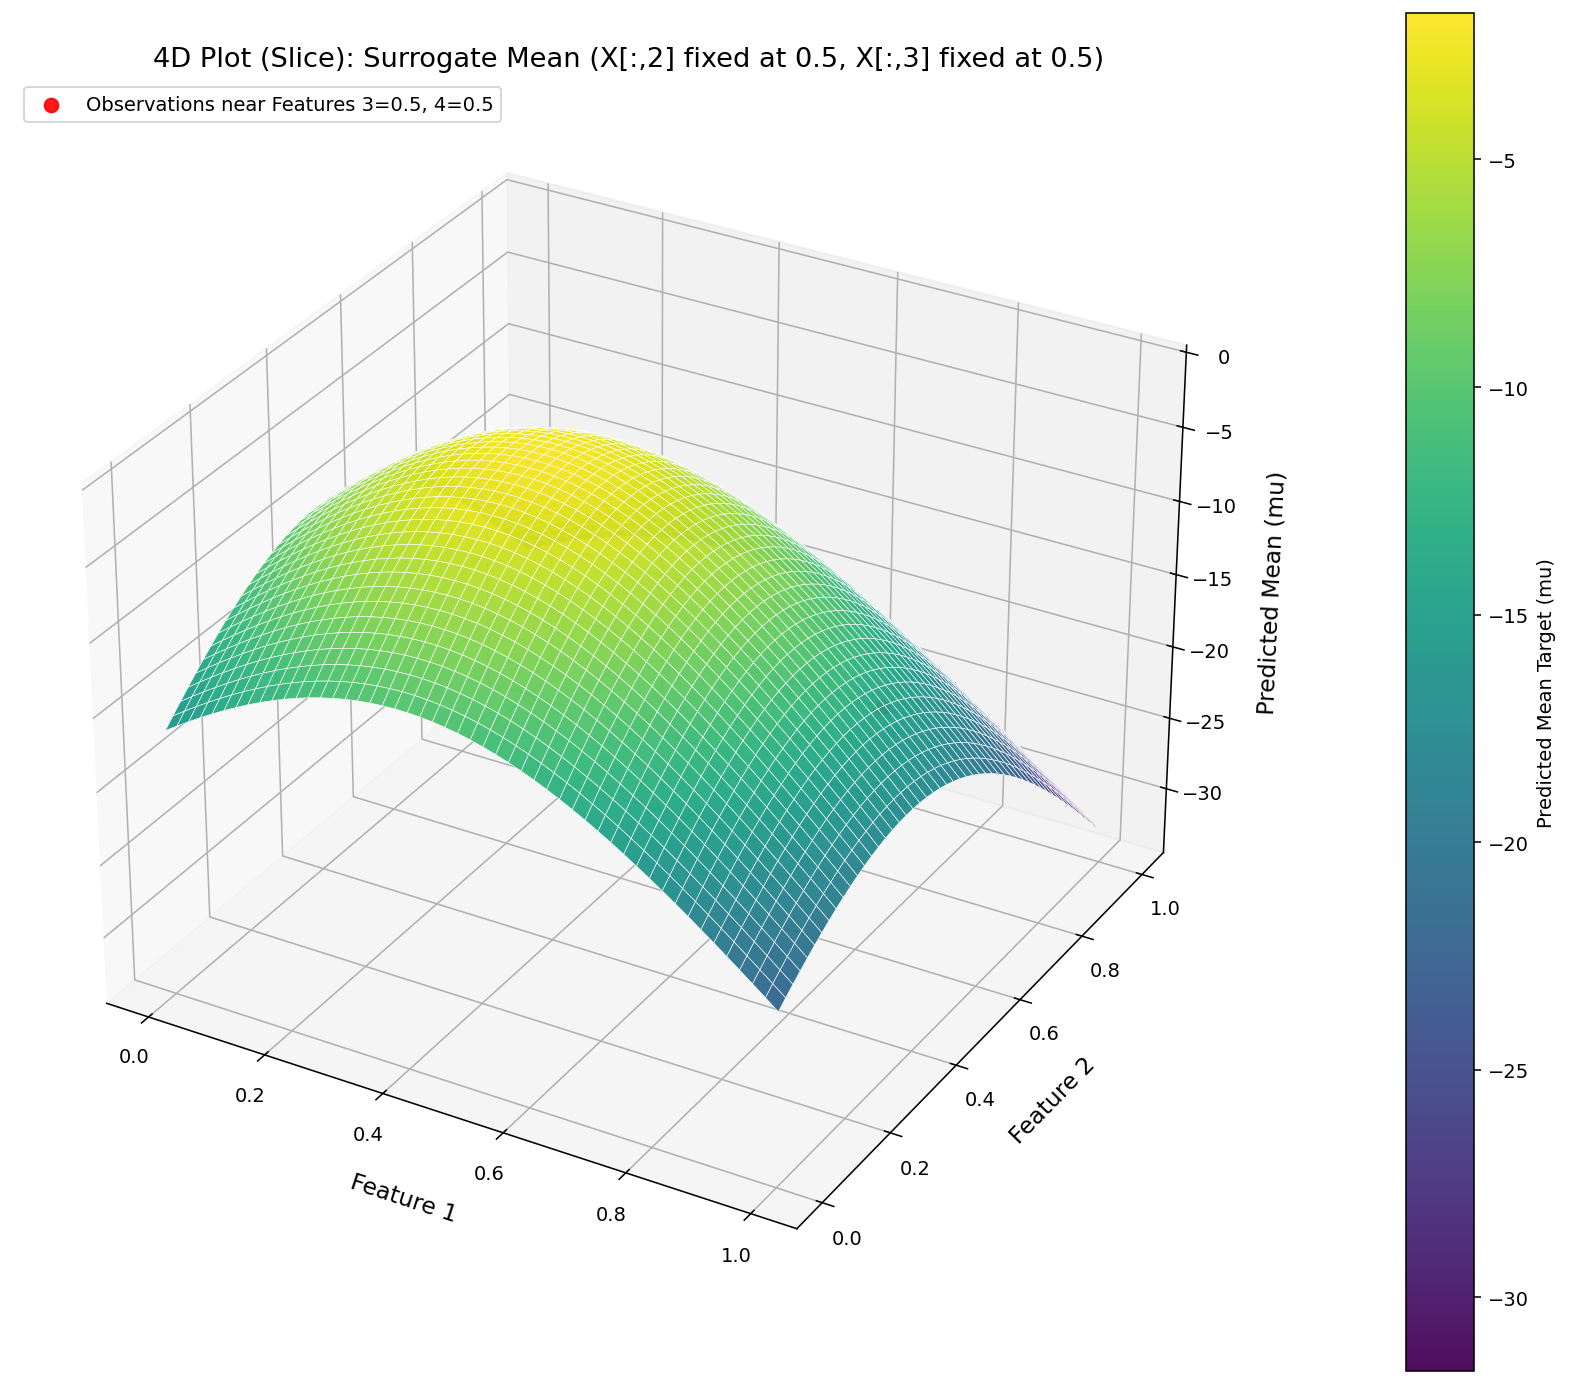

Displayed: 4D Slice Plot for Surrogate Mean (Features 3 fixed at 0.5, 4 fixed at 0.5)


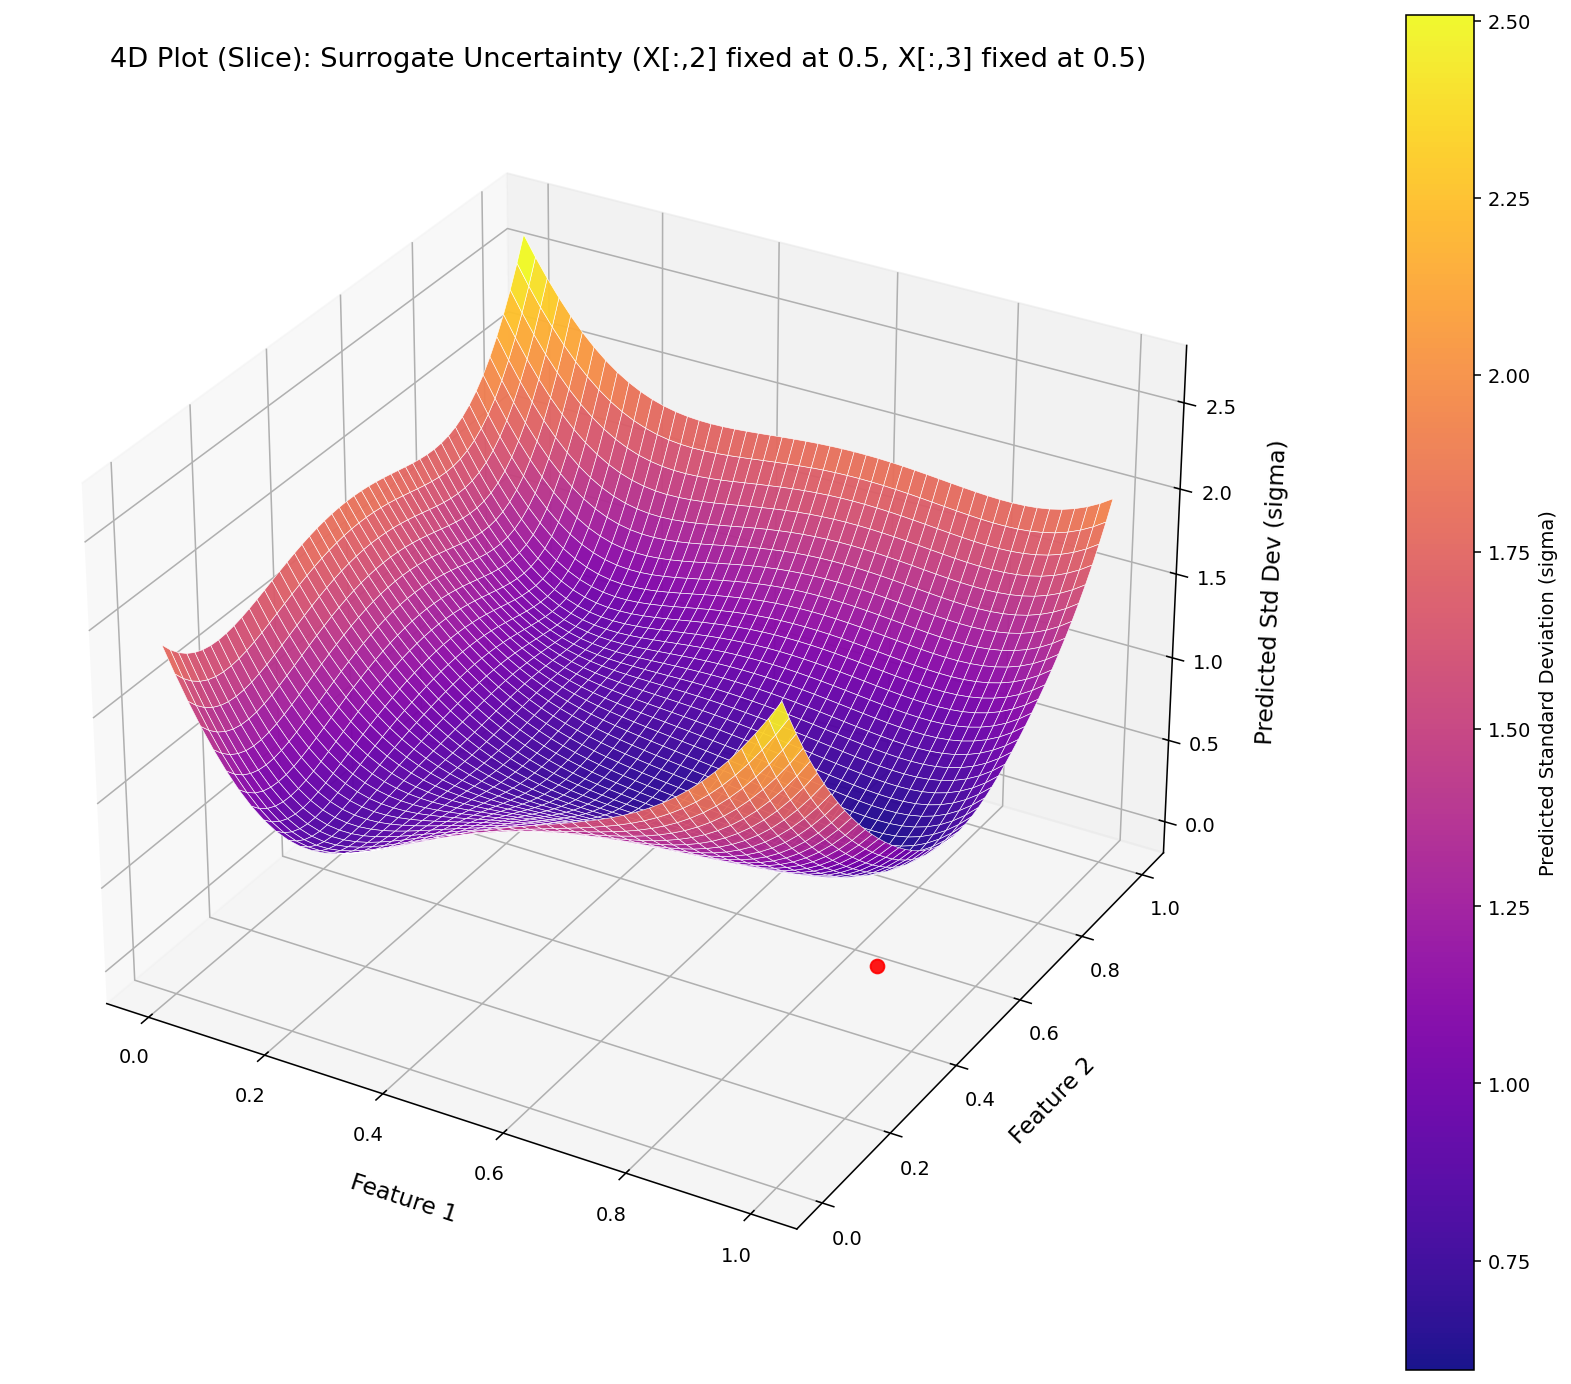

Displayed: 4D Slice Plot for Surrogate Uncertainty (Features 3 fixed at 0.5, 4 fixed at 0.5)


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# The gpr_3d model was defined and fitted in cell 'qd_rPFSHpykn'
gp = gpr_3d

# Observed data
X_obs = X # Global variable X from the notebook state (3D input)
y_obs = y # Global variable y from the notebook state (1D output)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 3', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data")

# ───────────────────────────────
# 2. 4D Plot (Slice): Surrogate Mean Surface by fixing Feature 3 and 4
#    This shows a 3D slice of the 4D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix Feature 3 (X[:,2]) at its mean or a chosen value (e.g., 0.5)
fixed_x3_value = 0.5 # Can also use np.mean(X_obs[:, 2])
fixed_x4_value = 0.5 # Fix Feature 4 (X[:,3]) at a chosen value

# Create the 4D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value), np.full(X1.size, fixed_x4_value)])

# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value
# (Optional: to show how observations relate to the slice)
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X_obs[:, 2] >= fixed_x3_value - tolerance) & (X_obs[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X_obs[:, 3] >= fixed_x4_value - tolerance) & (X_obs[:, 3] <= fixed_x4_value + tolerance))
ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}', alpha=0.9
)


# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'4D Plot (Slice): Surrogate Mean (X[:,2] fixed at {fixed_x3_value}, X[:,3] fixed at {fixed_x4_value})', fontsize=14)
ax2.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax2.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Mean (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})")

# ───────────────────────────────
# 3. 4D Plot (Slice): Surrogate Uncertainty Surface by fixing Features 3 and 4
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'4D Plot (Slice): Surrogate Uncertainty (X[:,2] fixed at {fixed_x3_value}, X[:,3] fixed at {fixed_x4_value})', fontsize=14)
ax3.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax3.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Uncertainty (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})")

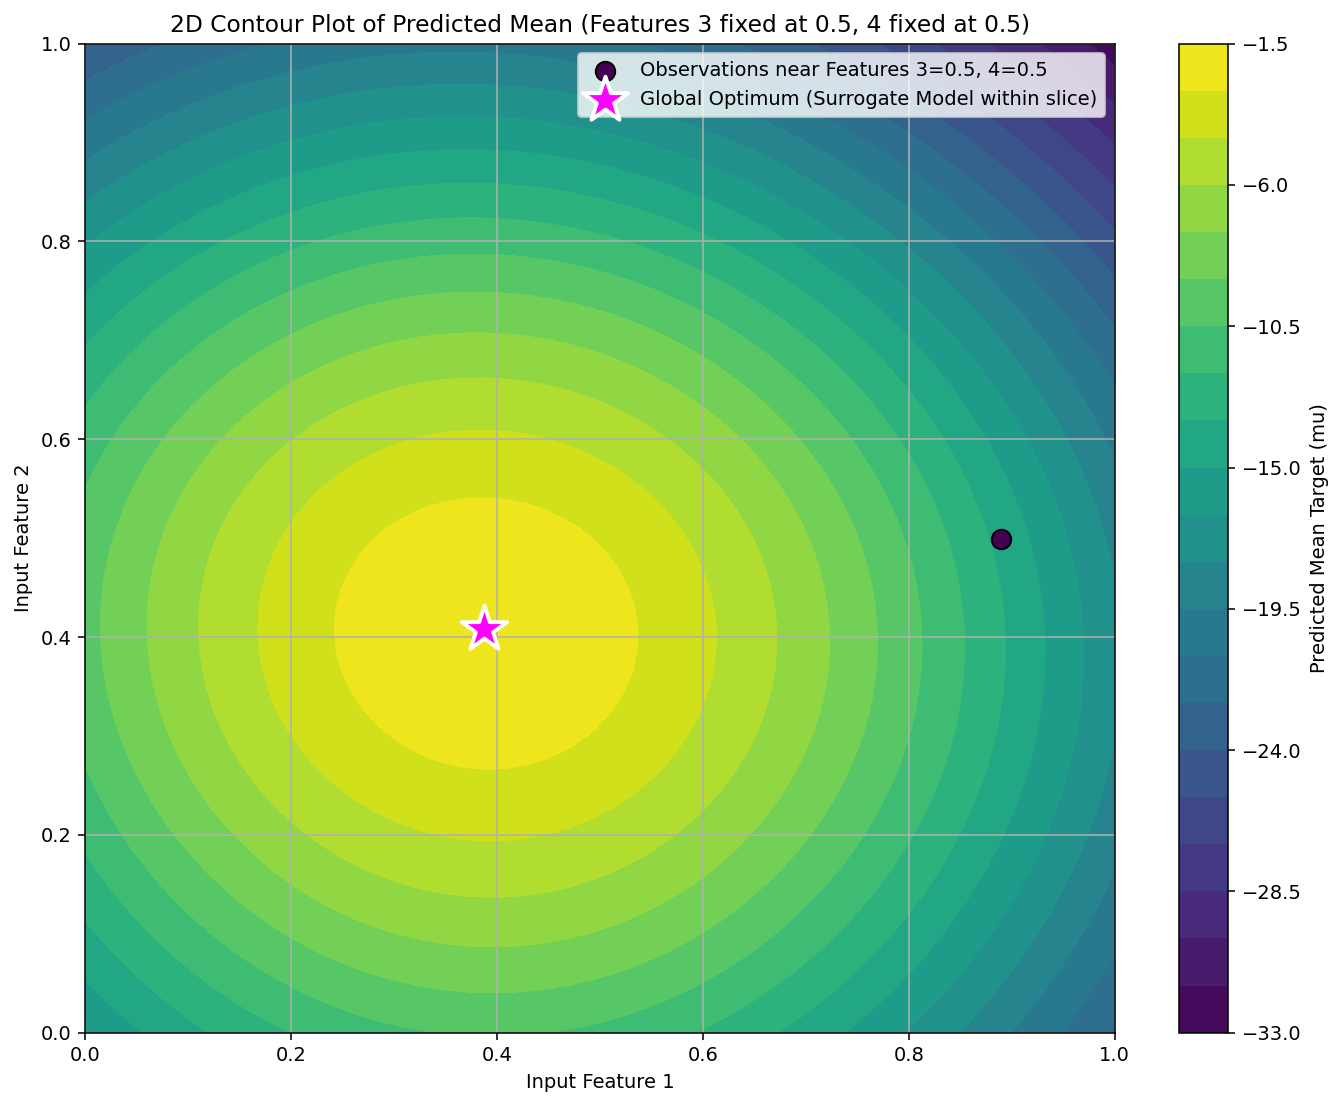

Saved: gp_surrogate_mean_contour_4d_input_slice.png


In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Define parameters for the 2D slice visualization (fixing Feature 3 and Feature 4)
fixed_x3_value = 0.5
fixed_x4_value = 0.5
resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 4D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value), np.full(X1.size, fixed_x4_value)])

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

plt.figure(figsize=(10, 8))
contour = plt.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
plt.colorbar(contour, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X[:, 2] >= fixed_x3_value - tolerance) & (X[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X[:, 3] >= fixed_x4_value - tolerance) & (X[:, 3] <= fixed_x4_value + tolerance))
plt.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}'
)

# Mark the suggested next sample point (if it falls within this slice)
# Check both fixed features for proximity
if np.isclose(next_x_data_point[2], fixed_x3_value, atol=tolerance) and \
   np.isclose(next_x_data_point[3], fixed_x4_value, atol=tolerance):
    plt.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice* (for the two varying features)
max_mu_slice_idx = np.argmax(Mu_slice_surface)
# Get the 4D coordinates of this point within the slice
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx]

plt.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label='Global Optimum (Surrogate Model within slice)'
)

plt.title(f'2D Contour Plot of Predicted Mean (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})')
plt.xlabel('Input Feature 1')
plt.ylabel('Input Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_4d_input_slice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean_contour_4d_input_slice.png")

In [80]:
import numpy as np

# --- 1. Global Maximum identified from Observed Data (y) ---
max_y_observed = np.max(y)
max_y_observed_idx = np.argmax(y)
max_X_observed = X[max_y_observed_idx]

print(f"\nObserved Global Maximum 'y' value: {max_y_observed:.5e}")
print(f"Corresponding 'X' values (Index {max_y_observed_idx}): {max_X_observed}")

# --- 2. Predicted Global Maximum (based on Surrogate Model gpr_3d) ---
# The gpr_3d model was already fitted in cell '4HScECjpuxOK' on X and y
# We will use the 'mu_3d' array which contains the predicted mean 'y' values for 'candidates_3d'

# Find the index of the maximum predicted mean 'y' value among all candidates
predicted_global_max_idx = np.argmax(mu_3d)
predicted_global_max_y = mu_3d[predicted_global_max_idx]
predicted_global_max_X = candidates_3d[predicted_global_max_idx]

# Get the uncertainty (standard deviation) at this predicted global maximum point
predicted_global_max_std = std_3d[predicted_global_max_idx]

print(f"\nPredicted Global Maximum 'y' value (from surrogate mean): {predicted_global_max_y:.5e}")
print(f"Corresponding 'X' values: {predicted_global_max_X}")
print(f"Uncertainty (std) at this predicted point: {predicted_global_max_std:.5e}")


Observed Global Maximum 'y' value: 4.28516e-01
Corresponding 'X' values (Index 39): [0.357388 0.399078 0.355108 0.439288]

Predicted Global Maximum 'y' value (from surrogate mean): -5.26825e-01
Corresponding 'X' values: [0.3951985  0.34060351 0.33252982 0.4304965 ]
Uncertainty (std) at this predicted point: 5.34666e-01
